### These: 
#### Länder mit höherem BIP pro Kopf haben eine höhere Lebenserwartung. Dargestellt in einem direkten Vergleich von jeweils 2 Ländern mit unterschiedlichem BIP pro Kopf und ähnlicher Einwohnerzahl

In [22]:
#Wichtige Imports
import pandas as pd
import matplotlib.pyplot as plt

Daten rauslesen für Portugal

In [19]:
import pandas as pd

# Load WHO dataset
df = pd.read_csv("Data_Files/base_data104_with_lookup.csv")

# Define countries to analyze
countries = [
    "Switzerland", "Portugal",
    "Republic of Korea", "Colombia",
    "Canada", "Poland",
    "Sweden", "Romania",
    "Japan", "Mexico"
]

# Count entries per year for each country
counts_dict = {}

for country in countries:
    counts = df[df["Country"] == country].groupby("Year").size()
    counts_dict[country] = counts

# Combine all countries side-by-side
comparison_all = pd.concat(counts_dict, axis=1)

# Replace missing values with 0 and cast to int
comparison_all = comparison_all.fillna(0).astype(int)

print("Vergleich der Einträge pro Jahr für ausgewählte Länder:")
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
display(comparison_all)


Vergleich der Einträge pro Jahr für ausgewählte Länder:


,Switzerland,Portugal,Republic of Korea,Colombia,Canada,Poland,Sweden,Romania,Japan,Mexico
Year,,,,,,,,,,
1995,2880,0,0,0,0,0,0,0,5456,0
1996,2809,0,0,0,0,0,0,0,5363,0
1997,2604,0,3550,4441,0,0,0,0,5306,0
1998,2707,0,3694,4532,0,0,0,0,5329,6287
1999,2679,0,3668,4493,0,4649,2579,3688,5434,6067
2000,2663,0,3989,4539,3845,4585,2575,3484,5390,5924
2001,2722,0,4021,4730,3796,4519,2509,3348,5275,5870
2002,2619,2652,4402,4680,3718,4425,2574,3283,5255,5847
2003,2696,2579,4330,4723,3731,4415,2536,3379,5349,5926


Years with full data across all countries: Index([2002, 2003, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016,
       2017, 2018, 2019],
      dtype='int64', name='Year')


<Axes: >

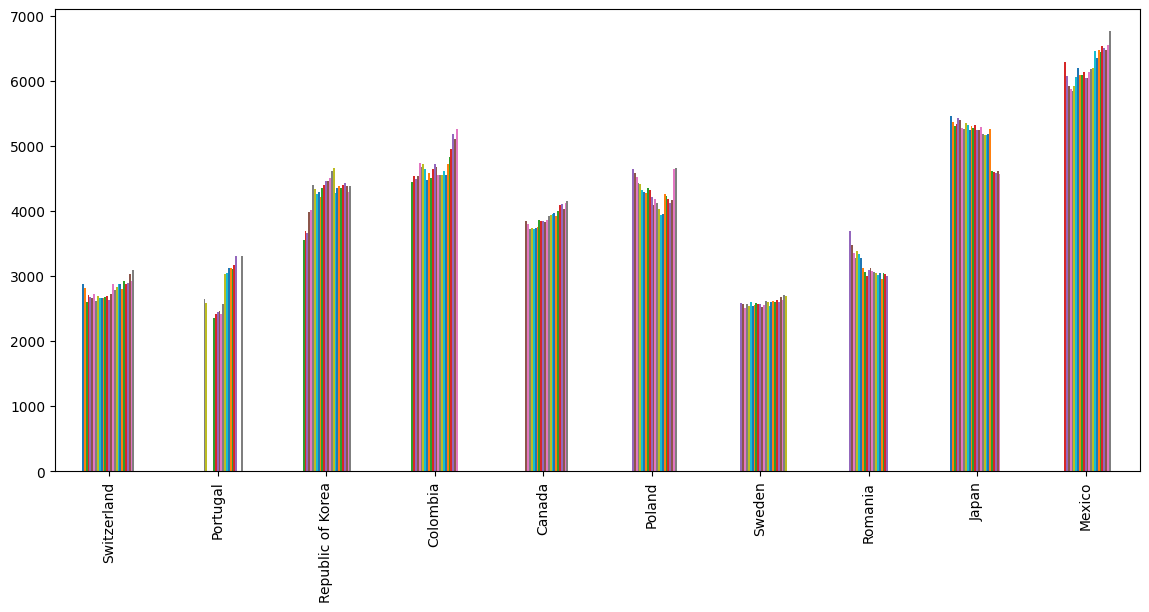

In [27]:
sorted(df["Country"].unique())

common_years = comparison_all[(comparison_all > 0).all(axis=1)].index
print("Years with full data across all countries:", common_years)
# Identify years with full data across all countries

comparison_all.T.plot(kind="bar", figsize=(14,6), legend=False)



In [28]:
import pandas as pd

# Years to include
years = [2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019]

# Your country pairs (similar population, different GDP)
country_pairs = [
    ("Switzerland", "Portugal"),
    ("Republic of Korea", "Colombia"),
    ("Japan", "Mexico")
]

death_col = "Deaths at all ages"

# Filter dataset for relevant years only
df_years = df[df["Year"].isin(years)].copy()

results = []

for country_a, country_b in country_pairs:
    # Keep only the two countries in the pair
    pair_df = df_years[df_years["Country"].isin([country_a, country_b])]

    # Count duplicates across both countries combined
    dup_count = pair_df.duplicated(subset=["Country", "Cause", "Sex"], keep=False).sum()

    # Count total rows (for context)
    total_rows = len(pair_df)

    results.append({
        "Pair": f"{country_a} vs {country_b}",
        "Years": f"{years[0]}–{years[-1]}",
        "Duplicates": dup_count,
        "Total Rows": total_rows,
        "Share (%)": round(dup_count / total_rows * 100, 2)
    })

# Turn into DataFrame for easy viewing
dup_summary = pd.DataFrame(results)
print(dup_summary)


                            Pair      Years  Duplicates  Total Rows  Share (%)
0        Switzerland vs Portugal  2007–2019       70283       73053      96.21
1  Republic of Korea vs Colombia  2007–2019      115916      118683      97.67
2                Japan vs Mexico  2007–2019      144795      147680      98.05


In [33]:
import pandas as pd

# Load WHO dataset
df = pd.read_csv("Data_Files/base_data104_with_lookup.csv")

# Define years and countries
years = list(range(2007, 2023))  # 2007–2019 inclusive
countries = [
    "Switzerland", "Portugal",
    "Republic of Korea", "Colombia",
    "Canada", "Poland",
    "Sweden", "Romania",
    "Japan", "Mexico"
]

death_col = "Deaths at all ages"

# Filter dataset
df_sub = df[df["Country"].isin(countries) & df["Year"].isin(years)].copy()

# Step 1️⃣ – Deduplicate per Country–Year–Cause–Sex, keep highest total (avoid double-counting)
df_unique = (
    df_sub
    .groupby(["Country", "Year", "Cause", "Sex"], as_index=False)[death_col]
    .max()
)

# Step 2️⃣ – Combine male + female totals to get total deaths per cause
df_total = (
    df_unique
    .groupby(["Country", "Year", "Cause"], as_index=False)[death_col]
    .sum()
)

# Step 3️⃣ – Example: show the top 10 causes by total deaths per country in 2019
year = 2022
for c in countries:
    print(f"\nTop 10 causes of death in {c} ({year}):")
    top10 = (
        df_total[(df_total["Country"] == c) & (df_total["Year"] == year)]
        .sort_values(death_col, ascending=False)
        .head(10)
    )
    print(top10.to_string(index=False))




Top 10 causes of death in Switzerland (2022):
    Country  Year                                                 Cause  Deaths at all ages
Switzerland  2022                                  Unspecified dementia                4878
Switzerland  2022 Other ill-defined and unspecified causes of mortality                4097
Switzerland  2022                            COVID-19, virus identified                4088
Switzerland  2022                         Atherosclerotic heart disease                3121
Switzerland  2022     Malignant neoplasm: Bronchus or lung, unspecified                2499
Switzerland  2022                            Heart failure, unspecified                1785
Switzerland  2022              Acute myocardial infarction, unspecified                1588
Switzerland  2022                        Malignant neoplasm of prostate                1347
Switzerland  2022                        Alzheimer disease, unspecified                1339
Switzerland  2022               M